# VexarDrive Fleet Analysis

2. Driver Behaviour Analysis

Identify differences in driver behaviour and determine which signals are useful
for measuring risky or abnormal driving patterns.e.model.

## Approach

Start at the trip and telemetry level, then aggregate to drivers.

Candidate features will be selected after looking at the data. Risk scoring
comes later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
PROCESSED_DIR = Path("../data/processed")

drivers = pd.read_parquet(PROCESSED_DIR / "drivers.parquet")
vehicles = pd.read_parquet(PROCESSED_DIR / "vehicles.parquet")
trips = pd.read_parquet(PROCESSED_DIR / "trips.parquet")
telemetry = pd.read_parquet(PROCESSED_DIR / "telemetry.parquet")

In [3]:
datasets = {
    "drivers": drivers,
    "vehicles": vehicles,
    "trips": trips,
    "telemetry": telemetry,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

drivers: (30, 8)
vehicles: (30, 8)
trips: (450, 14)
telemetry: (12987, 13)


## Driver Exposure

Before comparing drivers, check how much trip data we have for each one.

In [4]:
driver_exposure = (
    trips
    .groupby("Driver_ID")
    .agg(
        Trip_Count=("Trip_ID", "nunique"),
        Total_Duration_Min=("Duration_Min", "sum"),
        Total_Distance_KM=("Distance_KM", "sum"),
        Mean_Trip_Duration_Min=("Duration_Min", "mean"),
    )
    .reset_index()
)

driver_exposure

,Driver_ID,Trip_Count,Total_Duration_Min,Total_Distance_KM,Mean_Trip_Duration_Min
0,D01,15,427,185.370,28.467
1,D02,15,402,182.300,26.800
2,D03,15,482,200.360,32.133
3,D04,15,475,203.010,31.667
4,D05,15,482,258.600,32.133
5,D06,15,470,213.050,31.333
6,D07,15,462,217.020,30.800
7,D08,15,466,214.180,31.067
8,D09,15,396,239.860,26.400
9,D10,15,470,203.260,31.333


In [5]:
driver_exposure.describe().T

,count,mean,std,min,25%,50%,75%,max
Trip_Count,30.000,15.000,0.000,15.000,15.000,15.000,15.000,15.000
Total_Duration_Min,30.000,432.900,42.149,338.000,400.500,440.500,469.000,482.000
Total_Distance_KM,30.000,205.056,25.622,136.310,194.670,203.725,216.320,258.600
Mean_Trip_Duration_Min,30.000,28.860,2.810,22.533,26.700,29.367,31.267,32.133


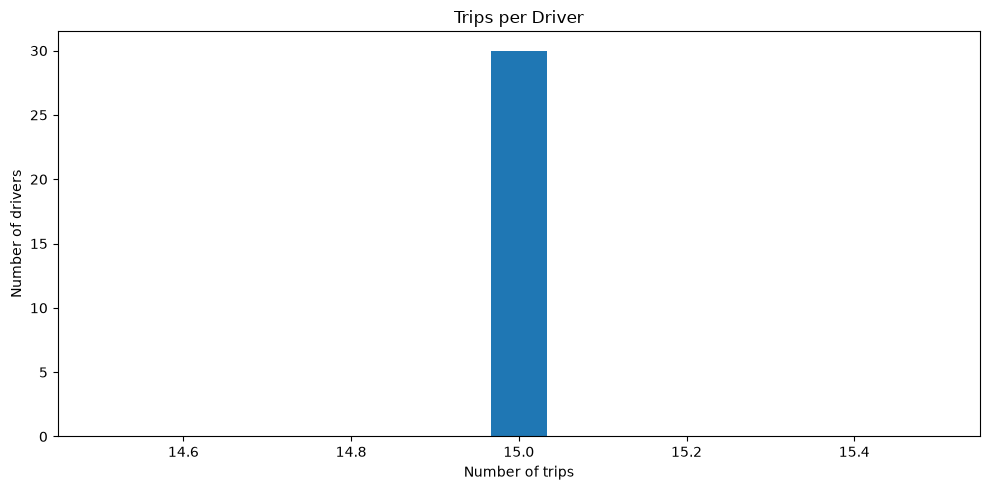

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(
    driver_exposure["Trip_Count"],
    bins=15
)

plt.title("Trips per Driver")
plt.xlabel("Number of trips")
plt.ylabel("Number of drivers")

plt.tight_layout()
plt.show()

In [7]:
driver_exposure.sort_values("Trip_Count").head(10)

,Driver_ID,Trip_Count,Total_Duration_Min,Total_Distance_KM,Mean_Trip_Duration_Min
0,D01,15,427,185.370,28.467
1,D02,15,402,182.300,26.800
2,D03,15,482,200.360,32.133
3,D04,15,475,203.010,31.667
4,D05,15,482,258.600,32.133
5,D06,15,470,213.050,31.333
6,D07,15,462,217.020,30.800
7,D08,15,466,214.180,31.067
8,D09,15,396,239.860,26.400
9,D10,15,470,203.260,31.333


In [8]:
driver_exposure.sort_values("Trip_Count", ascending=False).head(10)

,Driver_ID,Trip_Count,Total_Duration_Min,Total_Distance_KM,Mean_Trip_Duration_Min
0,D01,15,427,185.370,28.467
1,D02,15,402,182.300,26.800
2,D03,15,482,200.360,32.133
3,D04,15,475,203.010,31.667
4,D05,15,482,258.600,32.133
5,D06,15,470,213.050,31.333
6,D07,15,462,217.020,30.800
7,D08,15,466,214.180,31.067
8,D09,15,396,239.860,26.400
9,D10,15,470,203.260,31.333


## Speed Behaviour

Compare recorded trip speeds with telemetry-derived speed measures.

In [9]:
trip_speed_features = (
    telemetry
    .groupby("Trip_ID")
    .agg(
        Telemetry_Avg_Speed_kmph=("Speed_kmph", "mean"),
        Telemetry_Max_Speed_kmph=("Speed_kmph", "max"),
        Telemetry_P95_Speed_kmph=(
            "Speed_kmph",
            lambda x: x.quantile(0.95)
        ),
        Telemetry_Speed_Std_kmph=("Speed_kmph", "std"),
    )
    .reset_index()
)

trip_speed_features.head()

,Trip_ID,Telemetry_Avg_Speed_kmph,Telemetry_Max_Speed_kmph,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph
0,T00001,28.719,39.400,38.275,5.987
1,T00002,28.545,54.400,46.495,13.550
2,T00003,16.900,32.700,29.430,8.779
3,T00004,23.907,40.400,32.595,6.219
4,T00005,28.708,42.500,42.320,10.790


In [10]:
trip_speed = trips[
    [
        "Trip_ID",
        "Driver_ID",
        "Avg_Speed_kmph",
        "Max_Speed_kmph",
    ]
].merge(
    trip_speed_features,
    on="Trip_ID",
    how="left"
)

trip_speed.head()

,Trip_ID,Driver_ID,Avg_Speed_kmph,Max_Speed_kmph,Telemetry_Avg_Speed_kmph,Telemetry_Max_Speed_kmph,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph
0,T00001,D01,28.700,39.400,28.719,39.400,38.275,5.987
1,T00002,D01,28.500,54.400,28.545,54.400,46.495,13.550
2,T00003,D01,16.900,32.700,16.900,32.700,29.430,8.779
3,T00004,D01,23.900,40.400,23.907,40.400,32.595,6.219
4,T00005,D01,28.700,42.500,28.708,42.500,42.320,10.790


In [11]:
trip_speed[
    [
        "Avg_Speed_kmph",
        "Telemetry_Avg_Speed_kmph",
        "Max_Speed_kmph",
        "Telemetry_Max_Speed_kmph",
        "Telemetry_P95_Speed_kmph",
        "Telemetry_Speed_Std_kmph",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Speed_kmph,450.000,24.288,4.744,13.300,20.425,24.300,28.100,36.400
Telemetry_Avg_Speed_kmph,450.000,24.290,4.745,13.324,20.434,24.290,28.053,36.432
Max_Speed_kmph,450.000,42.002,9.975,23.100,34.625,40.400,47.875,73.600
Telemetry_Max_Speed_kmph,450.000,42.002,9.975,23.100,34.625,40.400,47.875,73.600
Telemetry_P95_Speed_kmph,450.000,37.816,7.882,22.450,32.001,37.285,43.073,62.125
Telemetry_Speed_Std_kmph,450.000,9.937,3.290,2.602,7.718,9.591,12.282,21.597


In [12]:
trip_speed[
    [
        "Avg_Speed_kmph",
        "Telemetry_Avg_Speed_kmph",
        "Max_Speed_kmph",
        "Telemetry_Max_Speed_kmph",
        "Telemetry_P95_Speed_kmph",
        "Telemetry_Speed_Std_kmph",
    ]
].corr()

,Avg_Speed_kmph,Telemetry_Avg_Speed_kmph,Max_Speed_kmph,Telemetry_Max_Speed_kmph,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph
Avg_Speed_kmph,1.000,1.000,0.521,0.521,0.655,0.209
Telemetry_Avg_Speed_kmph,1.000,1.000,0.521,0.521,0.655,0.209
Max_Speed_kmph,0.521,0.521,1.000,1.000,0.920,0.828
Telemetry_Max_Speed_kmph,0.521,0.521,1.000,1.000,0.920,0.828
Telemetry_P95_Speed_kmph,0.655,0.655,0.920,0.920,1.000,0.807
Telemetry_Speed_Std_kmph,0.209,0.209,0.828,0.828,0.807,1.000


speed_columns = [
    "Avg_Speed_kmph",
    "Max_Speed_kmph",
    "Telemetry_P95_Speed_kmph",
    "Telemetry_Speed_Std_kmph",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flat, speed_columns):
    ax.hist(
        trip_speed[column].dropna(),
        bins=20
    )
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Trips")

plt.tight_layout()
plt.show()

In [13]:
trip_speed[
    [
        "Avg_Speed_kmph",
        "Max_Speed_kmph",
        "Telemetry_P95_Speed_kmph",
        "Telemetry_Speed_Std_kmph",
    ]
].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

,Avg_Speed_kmph,Max_Speed_kmph,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph
0.500,24.300,40.400,37.285,9.591
0.750,28.100,47.875,43.073,12.282
0.900,30.610,56.210,48.044,14.726
0.950,31.700,60.410,52.043,15.666
0.990,34.651,69.555,58.239,17.129
1.000,36.400,73.600,62.125,21.597


## Driver-Level Speed

Check how the candidate speed measures differ between drivers.

In [14]:
driver_speed = (
    trip_speed
    .groupby("Driver_ID")
    .agg(
        Mean_Avg_Speed=(
            "Telemetry_Avg_Speed_kmph",
            "mean"
        ),
        Mean_Max_Speed=(
            "Telemetry_Max_Speed_kmph",
            "mean"
        ),
        Mean_P95_Speed=(
            "Telemetry_P95_Speed_kmph",
            "mean"
        ),
        Mean_Speed_Variability=(
            "Telemetry_Speed_Std_kmph",
            "mean"
        ),
        Trip_Count=("Trip_ID", "nunique"),
    )
    .reset_index()
)

driver_speed

,Driver_ID,Mean_Avg_Speed,Mean_Max_Speed,Mean_P95_Speed,Mean_Speed_Variability,Trip_Count
0,D01,25.382,42.093,38.055,9.312,15
1,D02,22.677,39.787,36.798,9.995,15
2,D03,22.853,51.847,44.427,13.183,15
3,D04,24.293,42.207,37.271,9.484,15
4,D05,23.017,32.407,29.997,6.248,15
5,D06,25.581,55.893,47.423,14.887,15
6,D07,25.277,41.100,37.705,9.677,15
7,D08,24.610,42.040,37.841,9.823,15
8,D09,25.708,34.873,33.291,7.081,15
9,D10,21.464,38.627,35.215,9.654,15


In [15]:
driver_speed.describe().T

,count,mean,std,min,25%,50%,75%,max
Mean_Avg_Speed,30.000,24.290,1.361,21.464,22.971,24.665,25.269,26.645
Mean_Max_Speed,30.000,42.002,7.546,31.420,35.583,41.023,43.032,57.713
Mean_P95_Speed,30.000,37.816,5.588,29.368,33.550,37.056,38.757,48.978
Mean_Speed_Variability,30.000,9.937,2.747,5.511,7.692,9.740,10.118,14.906
Trip_Count,30.000,15.000,0.000,15.000,15.000,15.000,15.000,15.000


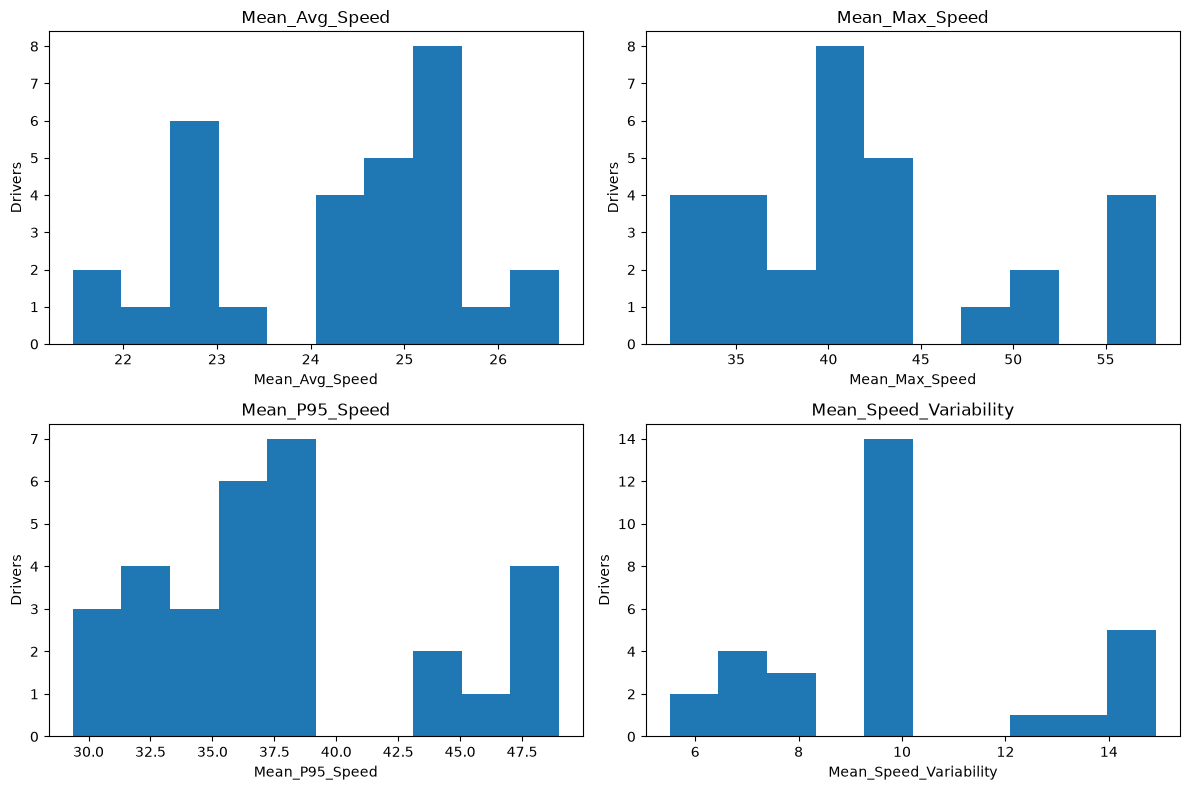

In [16]:
driver_speed_columns = [
    "Mean_Avg_Speed",
    "Mean_Max_Speed",
    "Mean_P95_Speed",
    "Mean_Speed_Variability",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flat, driver_speed_columns):
    ax.hist(
        driver_speed[column].dropna(),
        bins=10
    )
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Drivers")

plt.tight_layout()
plt.show()

## Acceleration

Check whether the acceleration data gives us a useful behavioural signal.

In [17]:
telemetry["Accel_Magnitude_g"] = np.sqrt(
    telemetry["Accel_X_g"] ** 2
    + telemetry["Accel_Y_g"] ** 2
    + telemetry["Accel_Z_g"] ** 2
)

telemetry["Accel_Magnitude_g"].describe()

count   12,987.000
mean         1.022
std          0.086
min          0.764
25%          0.980
50%          1.009
75%          1.040
max          1.968
Name: Accel_Magnitude_g, dtype: float64

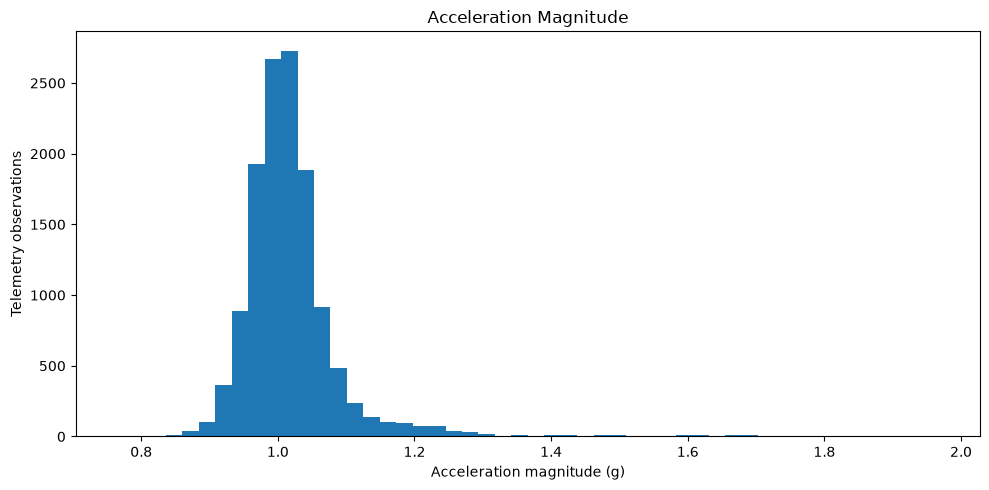

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    telemetry["Accel_Magnitude_g"].dropna(),
    bins=50
)

plt.title("Acceleration Magnitude")
plt.xlabel("Acceleration magnitude (g)")
plt.ylabel("Telemetry observations")

plt.tight_layout()
plt.show()

In [19]:
telemetry["Accel_Magnitude_g"].quantile(
    [
        0,
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1.00,
    ]
)

0.000   0.764
0.010   0.906
0.050   0.938
0.250   0.980
0.500   1.009
0.750   1.040
0.900   1.083
0.950   1.141
0.990   1.427
1.000   1.968
Name: Accel_Magnitude_g, dtype: float64

## Acceleration Axes

Look at the individual axes before deciding whether braking or acceleration
can be identified directionally.

In [20]:
accel_columns = ["Accel_X_g", "Accel_Y_g", "Accel_Z_g",]

telemetry[accel_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Accel_X_g,"12,987.000",0.002,0.156,-0.825,-0.042,0.000,0.042,0.898
Accel_Y_g,"12,987.000",0.001,0.087,-0.578,-0.039,0.000,0.040,0.579
Accel_Z_g,"12,987.000",1.007,0.076,0.763,0.974,1.001,1.028,1.869


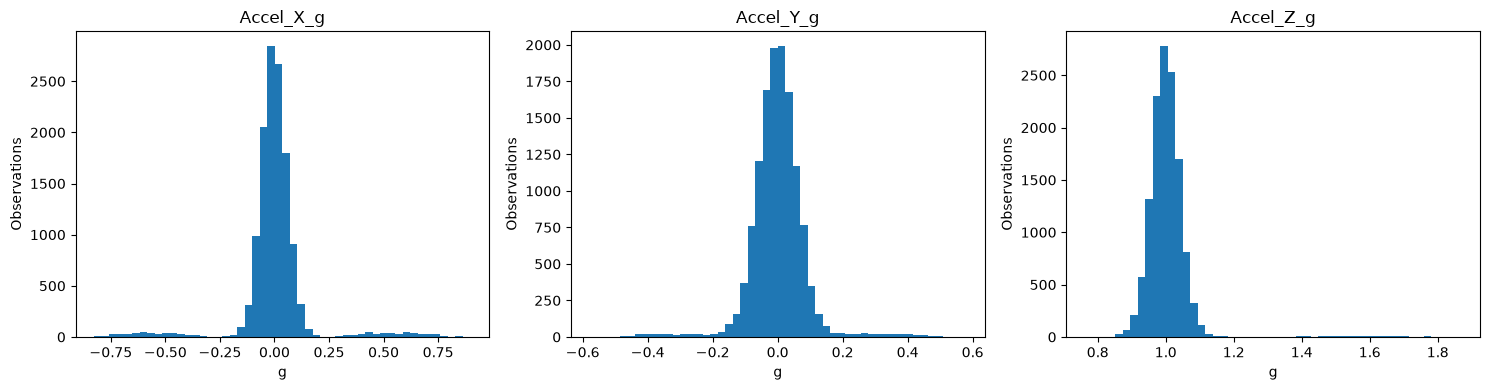

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, accel_columns):
    ax.hist(
        telemetry[column].dropna(),
        bins=50
    )
    ax.set_title(column)
    ax.set_xlabel("g")
    ax.set_ylabel("Observations")

plt.tight_layout()
plt.show()

## Driver-Level Acceleration

Compare acceleration behaviour across drivers.

In [22]:
telemetry_driver = telemetry[
    [
        "Trip_ID",
        "Accel_Magnitude_g",
    ]
].merge(
    trips[
        [
            "Trip_ID",
            "Driver_ID",
        ]
    ],
    on="Trip_ID",
    how="left"
)

driver_acceleration = (
    telemetry_driver
    .groupby("Driver_ID")
    .agg(
        Mean_Accel_Magnitude=(
            "Accel_Magnitude_g",
            "mean"
        ),
        Std_Accel_Magnitude=(
            "Accel_Magnitude_g",
            "std"
        ),
        P95_Accel_Magnitude=(
            "Accel_Magnitude_g",
            lambda x: x.quantile(0.95)
        ),
        P99_Accel_Magnitude=(
            "Accel_Magnitude_g",
            lambda x: x.quantile(0.99)
        ),
        Max_Accel_Magnitude=(
            "Accel_Magnitude_g",
            "max"
        ),
        Telemetry_Count=(
            "Accel_Magnitude_g",
            "size"
        ),
    )
    .reset_index()
)

driver_acceleration

,Driver_ID,Mean_Accel_Magnitude,Std_Accel_Magnitude,P95_Accel_Magnitude,P99_Accel_Magnitude,Max_Accel_Magnitude,Telemetry_Count
0,D01,1.025,0.090,1.184,1.400,1.640,427
1,D02,1.047,0.158,1.427,1.718,1.813,402
2,D03,1.032,0.067,1.169,1.251,1.476,482
3,D04,1.013,0.059,1.099,1.192,1.561,475
4,D05,1.011,0.072,1.067,1.428,1.663,482
5,D06,1.022,0.065,1.175,1.239,1.373,470
6,D07,1.016,0.056,1.090,1.217,1.493,462
7,D08,1.018,0.079,1.133,1.266,1.783,466
8,D09,1.010,0.063,1.075,1.224,1.760,396
9,D10,1.026,0.097,1.133,1.550,1.788,470


In [23]:
driver_acceleration.describe().T

,count,mean,std,min,25%,50%,75%,max
Mean_Accel_Magnitude,30.000,1.022,0.010,1.009,1.013,1.019,1.027,1.047
Std_Accel_Magnitude,30.000,0.083,0.023,0.056,0.068,0.076,0.096,0.158
P95_Accel_Magnitude,30.000,1.140,0.072,1.065,1.090,1.126,1.173,1.427
P99_Accel_Magnitude,30.000,1.362,0.155,1.192,1.237,1.300,1.485,1.718
Max_Accel_Magnitude,30.000,1.713,0.132,1.373,1.663,1.749,1.783,1.968
Telemetry_Count,30.000,432.900,42.149,338.000,400.500,440.500,469.000,482.000


## Gyroscope

Check whether rotational behaviour gives us a useful signal for
manoeuvring/turning behaviour.

In [24]:
telemetry["Gyro_Magnitude_dps"] = np.sqrt(
    telemetry["Gyro_X_dps"] ** 2
    + telemetry["Gyro_Y_dps"] ** 2
    + telemetry["Gyro_Z_dps"] ** 2
)

telemetry["Gyro_Magnitude_dps"].describe()

count   12,987.000
mean         4.716
std          7.503
min          0.107
25%          2.255
50%          3.176
75%          4.241
max         58.206
Name: Gyro_Magnitude_dps, dtype: float64

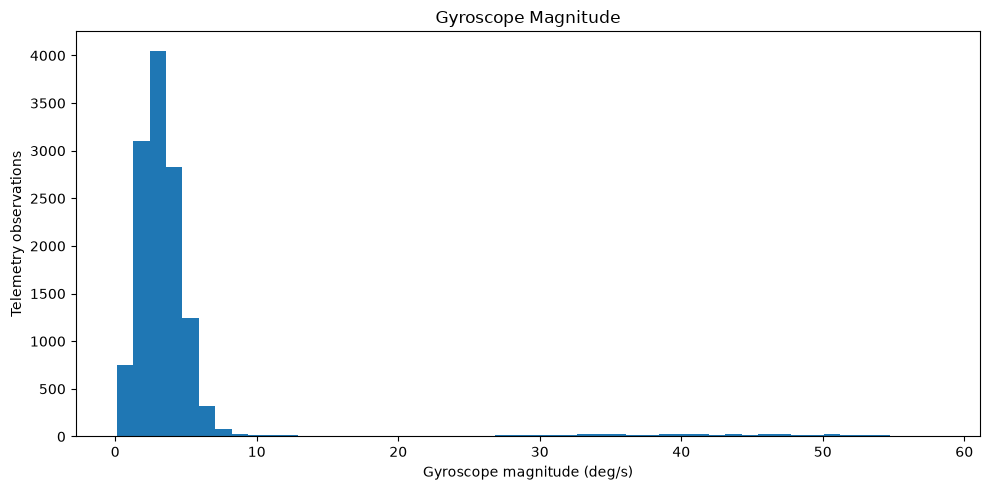

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    telemetry["Gyro_Magnitude_dps"].dropna(),
    bins=50
)

plt.title("Gyroscope Magnitude")
plt.xlabel("Gyroscope magnitude (deg/s)")
plt.ylabel("Telemetry observations")

plt.tight_layout()
plt.show()

In [26]:
telemetry["Gyro_Magnitude_dps"].quantile(
    [
        0,
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1.00,
    ]
)

0.000    0.107
0.010    0.669
0.050    1.211
0.250    2.255
0.500    3.176
0.750    4.241
0.900    5.535
0.950    7.576
0.990   47.014
1.000   58.206
Name: Gyro_Magnitude_dps, dtype: float64

In [27]:
telemetry_driver_gyro = telemetry[
    [
        "Trip_ID",
        "Gyro_Magnitude_dps",
    ]
].merge(
    trips[
        [
            "Trip_ID",
            "Driver_ID",
        ]
    ],
    on="Trip_ID",
    how="left"
)

driver_gyro = (
    telemetry_driver_gyro
    .groupby("Driver_ID")
    .agg(
        Mean_Gyro_Magnitude=(
            "Gyro_Magnitude_dps",
            "mean"
        ),
        Std_Gyro_Magnitude=(
            "Gyro_Magnitude_dps",
            "std"
        ),
        P95_Gyro_Magnitude=(
            "Gyro_Magnitude_dps",
            lambda x: x.quantile(0.95)
        ),
        P99_Gyro_Magnitude=(
            "Gyro_Magnitude_dps",
            lambda x: x.quantile(0.99)
        ),
        Max_Gyro_Magnitude=(
            "Gyro_Magnitude_dps",
            "max"
        ),
    )
    .reset_index()
)

driver_gyro

,Driver_ID,Mean_Gyro_Magnitude,Std_Gyro_Magnitude,P95_Gyro_Magnitude,P99_Gyro_Magnitude,Max_Gyro_Magnitude
0,D01,5.442,9.350,29.445,51.358,54.095
1,D02,5.032,7.255,16.693,45.505,52.920
2,D03,5.514,9.227,30.811,50.900,54.574
3,D04,5.145,8.309,25.854,46.188,54.671
4,D05,4.008,5.486,6.458,41.288,45.815
5,D06,5.505,9.294,33.088,48.460,54.202
6,D07,4.679,7.688,6.642,46.077,53.352
7,D08,4.439,6.870,6.622,42.489,52.290
8,D09,3.500,3.668,5.743,8.753,52.668
9,D10,4.637,7.257,7.041,48.878,55.001


## Candidate Features

Bring the driver-level measures together and compare them.

In [28]:
driver_candidates = (
    driver_exposure
    .merge(
        driver_speed,
        on="Driver_ID",
        how="outer",
        suffixes=("_exposure", "_speed")
    )
    .merge(
        driver_acceleration,
        on="Driver_ID",
        how="outer"
    )
    .merge(
        driver_gyro,
        on="Driver_ID",
        how="outer"
    )
)

driver_candidates

,Driver_ID,Trip_Count_exposure,Total_Duration_Min,Total_Distance_KM,Mean_Trip_Duration_Min,Mean_Avg_Speed,Mean_Max_Speed,Mean_P95_Speed,Mean_Speed_Variability,Trip_Count_speed,Mean_Accel_Magnitude,Std_Accel_Magnitude,P95_Accel_Magnitude,P99_Accel_Magnitude,Max_Accel_Magnitude,Telemetry_Count,Mean_Gyro_Magnitude,Std_Gyro_Magnitude,P95_Gyro_Magnitude,P99_Gyro_Magnitude,Max_Gyro_Magnitude
0,D01,15,427,185.370,28.467,25.382,42.093,38.055,9.312,15,1.025,0.090,1.184,1.400,1.640,427,5.442,9.350,29.445,51.358,54.095
1,D02,15,402,182.300,26.800,22.677,39.787,36.798,9.995,15,1.047,0.158,1.427,1.718,1.813,402,5.032,7.255,16.693,45.505,52.920
2,D03,15,482,200.360,32.133,22.853,51.847,44.427,13.183,15,1.032,0.067,1.169,1.251,1.476,482,5.514,9.227,30.811,50.900,54.574
3,D04,15,475,203.010,31.667,24.293,42.207,37.271,9.484,15,1.013,0.059,1.099,1.192,1.561,475,5.145,8.309,25.854,46.188,54.671
4,D05,15,482,258.600,32.133,23.017,32.407,29.997,6.248,15,1.011,0.072,1.067,1.428,1.663,482,4.008,5.486,6.458,41.288,45.815
5,D06,15,470,213.050,31.333,25.581,55.893,47.423,14.887,15,1.022,0.065,1.175,1.239,1.373,470,5.505,9.294,33.088,48.460,54.202
6,D07,15,462,217.020,30.800,25.277,41.100,37.705,9.677,15,1.016,0.056,1.090,1.217,1.493,462,4.679,7.688,6.642,46.077,53.352
7,D08,15,466,214.180,31.067,24.610,42.040,37.841,9.823,15,1.018,0.079,1.133,1.266,1.783,466,4.439,6.870,6.622,42.489,52.290
8,D09,15,396,239.860,26.400,25.708,34.873,33.291,7.081,15,1.010,0.063,1.075,1.224,1.760,396,3.500,3.668,5.743,8.753,52.668
9,D10,15,470,203.260,31.333,21.464,38.627,35.215,9.654,15,1.026,0.097,1.133,1.550,1.788,470,4.637,7.257,7.041,48.878,55.001


In [29]:
candidate_numeric = driver_candidates.select_dtypes(
    include=np.number
)

candidate_numeric.corr()

,Trip_Count_exposure,Total_Duration_Min,Total_Distance_KM,Mean_Trip_Duration_Min,Mean_Avg_Speed,Mean_Max_Speed,Mean_P95_Speed,Mean_Speed_Variability,Trip_Count_speed,Mean_Accel_Magnitude,Std_Accel_Magnitude,P95_Accel_Magnitude,P99_Accel_Magnitude,Max_Accel_Magnitude,Telemetry_Count,Mean_Gyro_Magnitude,Std_Gyro_Magnitude,P95_Gyro_Magnitude,P99_Gyro_Magnitude,Max_Gyro_Magnitude
Trip_Count_exposure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Duration_Min,NaN,1.000,0.635,1.000,-0.151,0.098,0.029,0.068,NaN,-0.181,-0.196,-0.157,-0.107,-0.241,1.000,0.078,0.074,0.067,0.198,-0.136
Total_Distance_KM,NaN,0.635,1.000,0.635,-0.039,-0.414,-0.462,-0.465,NaN,-0.617,-0.399,-0.493,-0.230,-0.215,0.635,-0.502,-0.515,-0.417,-0.375,-0.354
Mean_Trip_Duration_Min,NaN,1.000,0.635,1.000,-0.151,0.098,0.029,0.068,NaN,-0.181,-0.196,-0.157,-0.107,-0.241,1.000,0.078,0.074,0.067,0.198,-0.136
Mean_Avg_Speed,NaN,-0.151,-0.039,-0.151,1.000,0.303,0.338,0.172,NaN,-0.042,-0.161,-0.060,-0.254,-0.025,-0.151,-0.010,0.032,0.139,-0.228,-0.073
Mean_Max_Speed,NaN,0.098,-0.414,0.098,0.303,1.000,0.994,0.977,NaN,0.695,0.302,0.521,0.204,-0.084,0.098,0.810,0.823,0.823,0.496,0.386
Mean_P95_Speed,NaN,0.029,-0.462,0.029,0.338,0.994,1.000,0.976,NaN,0.716,0.328,0.541,0.219,-0.056,0.029,0.801,0.814,0.802,0.479,0.377
Mean_Speed_Variability,NaN,0.068,-0.465,0.068,0.172,0.977,0.976,1.000,NaN,0.751,0.388,0.577,0.286,-0.017,0.068,0.821,0.825,0.802,0.533,0.362
Trip_Count_speed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mean_Accel_Magnitude,NaN,-0.181,-0.617,-0.181,-0.042,0.695,0.716,0.751,NaN,1.000,0.824,0.899,0.696,0.241,-0.181,0.740,0.690,0.675,0.541,0.305


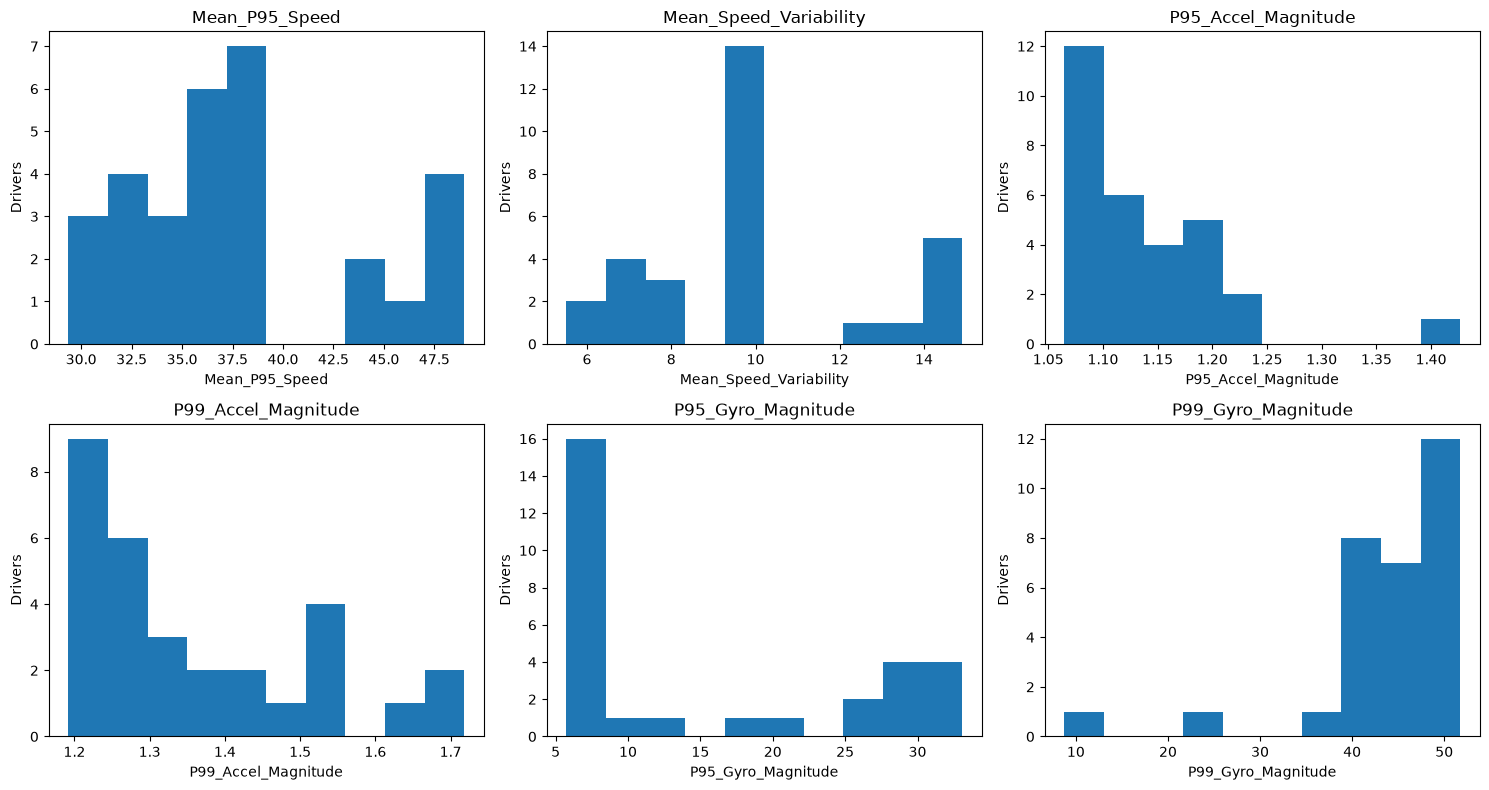

In [30]:
candidate_columns = [
    "Mean_P95_Speed",
    "Mean_Speed_Variability",
    "P95_Accel_Magnitude",
    "P99_Accel_Magnitude",
    "P95_Gyro_Magnitude",
    "P99_Gyro_Magnitude",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat, candidate_columns):
    ax.hist(
        driver_candidates[column].dropna(),
        bins=10
    )
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Drivers")

plt.tight_layout()
plt.show()

## Acceleration Revisited

The Z axis is centred around 1g, so raw acceleration magnitude includes the
gravity component.

Test alternative measures before using acceleration in the final analysis.

In [31]:
telemetry["Accel_Horizontal_g"] = np.sqrt(telemetry["Accel_X_g"] ** 2 + telemetry["Accel_Y_g"] ** 2)

telemetry["Accel_Dynamic_g"] = np.sqrt(telemetry["Accel_X_g"] ** 2 + telemetry["Accel_Y_g"] ** 2 + (telemetry["Accel_Z_g"] - 1.0) ** 2)

telemetry[
    [
        "Accel_Magnitude_g",
        "Accel_Horizontal_g",
        "Accel_Dynamic_g"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Accel_Magnitude_g,"12,987.000",1.022,0.086,0.764,0.980,1.009,1.040,1.968
Accel_Horizontal_g,"12,987.000",0.113,0.138,0.001,0.045,0.072,0.108,0.902
Accel_Dynamic_g,"12,987.000",0.129,0.145,0.003,0.058,0.085,0.121,1.065


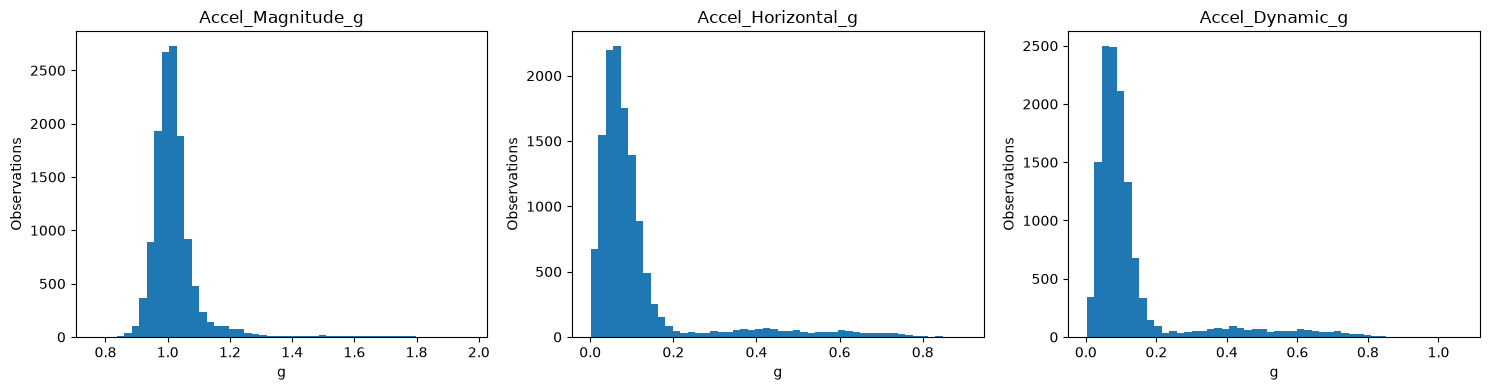

In [32]:
accel_candidates = [
    "Accel_Magnitude_g",
    "Accel_Horizontal_g",
    "Accel_Dynamic_g"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, accel_candidates):
    ax.hist(
        telemetry[column].dropna(),
        bins=50
    )
    ax.set_title(column)
    ax.set_xlabel("g")
    ax.set_ylabel("Observations")

plt.tight_layout()
plt.show()

In [33]:
accel_driver = (
    telemetry[
        [
            "Trip_ID",
            "Accel_Horizontal_g",
            "Accel_Dynamic_g"
        ]
    ]
    .merge(
        trips[["Trip_ID", "Driver_ID"]],
        on="Trip_ID",
        how="left"
    )
    .groupby("Driver_ID")
    .agg(
        Mean_Horizontal_Accel=(
            "Accel_Horizontal_g",
            "mean"
        ),
        P95_Horizontal_Accel=(
            "Accel_Horizontal_g",
            lambda x: x.quantile(0.95)
        ),
        P99_Horizontal_Accel=(
            "Accel_Horizontal_g",
            lambda x: x.quantile(0.99)
        ),
        Mean_Dynamic_Accel=(
            "Accel_Dynamic_g",
            "mean"
        ),
        P95_Dynamic_Accel=(
            "Accel_Dynamic_g",
            lambda x: x.quantile(0.95)
        ),
        P99_Dynamic_Accel=(
            "Accel_Dynamic_g",
            lambda x: x.quantile(0.99)
        ),
    )
    .reset_index()
)

accel_driver

,Driver_ID,Mean_Horizontal_Accel,P95_Horizontal_Accel,P99_Horizontal_Accel,Mean_Dynamic_Accel,P95_Dynamic_Accel,P99_Dynamic_Accel
0,D01,0.123,0.495,0.757,0.141,0.517,0.757
1,D02,0.130,0.417,0.581,0.182,0.520,0.741
2,D03,0.154,0.619,0.737,0.162,0.619,0.738
3,D04,0.097,0.380,0.601,0.107,0.399,0.604
4,D05,0.077,0.143,0.383,0.092,0.160,0.563
5,D06,0.146,0.597,0.745,0.153,0.598,0.746
6,D07,0.101,0.421,0.623,0.111,0.431,0.624
7,D08,0.103,0.442,0.689,0.116,0.455,0.713
8,D09,0.085,0.160,0.601,0.097,0.174,0.631
9,D10,0.108,0.395,0.664,0.129,0.500,0.685


## Extreme Behaviour Frequency

Percentiles show how extreme behaviour gets.

Now check how often extreme observations actually occur.

In [34]:
speed_p95 = telemetry["Speed_kmph"].quantile(0.95)
speed_p99 = telemetry["Speed_kmph"].quantile(0.99)

gyro_p95 = telemetry["Gyro_Magnitude_dps"].quantile(0.95)
gyro_p99 = telemetry["Gyro_Magnitude_dps"].quantile(0.99)

print("Fleet speed P95:", speed_p95)
print("Fleet speed P99:", speed_p99)
print("Fleet gyro P95:", gyro_p95)
print("Fleet gyro P99:", gyro_p99)

Fleet speed P95: 41.8
Fleet speed P99: 51.3
Fleet gyro P95: 7.575581189337716
Fleet gyro P99: 47.013925454626886


In [35]:
telemetry["High_Speed"] = (telemetry["Speed_kmph"] >= speed_p95)
telemetry["Extreme_Speed"] = (telemetry["Speed_kmph"] >= speed_p99)
telemetry["High_Gyro"] = (telemetry["Gyro_Magnitude_dps"] >= gyro_p95)
telemetry["Extreme_Gyro"] = (telemetry["Gyro_Magnitude_dps"] >= gyro_p99)

In [36]:
telemetry_driver_events = telemetry[
    [
        "Trip_ID",
        "High_Speed",
        "Extreme_Speed",
        "High_Gyro",
        "Extreme_Gyro",
    ]
].merge(
    trips[["Trip_ID", "Driver_ID"]],
    on="Trip_ID",
    how="left",
    validate="many_to_one"
)

driver_event_frequency = (
    telemetry_driver_events
    .groupby("Driver_ID")
    .agg(
        High_Speed_Rate=("High_Speed", "mean"),
        Extreme_Speed_Rate=("Extreme_Speed", "mean"),
        High_Gyro_Rate=("High_Gyro", "mean"),
        Extreme_Gyro_Rate=("Extreme_Gyro", "mean"),
    )
    .reset_index()
)

driver_event_frequency

,Driver_ID,High_Speed_Rate,Extreme_Speed_Rate,High_Gyro_Rate,Extreme_Gyro_Rate
0,D01,0.044,0.002,0.066,0.021
1,D02,0.032,0.000,0.090,0.007
2,D03,0.093,0.025,0.068,0.017
3,D04,0.046,0.002,0.059,0.008
4,D05,0.004,0.000,0.031,0.000
5,D06,0.155,0.049,0.066,0.019
6,D07,0.052,0.002,0.043,0.009
7,D08,0.034,0.002,0.041,0.006
8,D09,0.000,0.000,0.013,0.003
9,D10,0.028,0.004,0.043,0.013


In [37]:
driver_event_frequency.describe().T

,count,mean,std,min,25%,50%,75%,max
High_Speed_Rate,30.000,0.050,0.052,0.000,0.006,0.039,0.051,0.165
Extreme_Speed_Rate,30.000,0.010,0.018,0.000,0.000,0.002,0.005,0.052
High_Gyro_Rate,30.000,0.050,0.020,0.013,0.036,0.051,0.065,0.090
Extreme_Gyro_Rate,30.000,0.010,0.006,0.000,0.006,0.009,0.014,0.021


## Trip Context

Check whether the behavioural signals are strongly related to trip distance
or duration.

In [38]:
trip_context = trip_speed.merge(
    trips[
        [
            "Trip_ID",
            "Distance_KM",
            "Duration_Min"
        ]
    ],
    on="Trip_ID",
    how="left"
)

trip_context[
    [
        "Distance_KM",
        "Duration_Min",
        "Avg_Speed_kmph",
        "Telemetry_P95_Speed_kmph",
        "Telemetry_Speed_Std_kmph"
    ]
].corr()

,Distance_KM,Duration_Min,Avg_Speed_kmph,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph
Distance_KM,1.000,0.662,-0.012,-0.059,-0.091
Duration_Min,0.662,1.000,-0.059,0.033,0.020
Avg_Speed_kmph,-0.012,-0.059,1.000,0.655,0.209
Telemetry_P95_Speed_kmph,-0.059,0.033,0.655,1.000,0.807
Telemetry_Speed_Std_kmph,-0.091,0.020,0.209,0.807,1.000


In [39]:
trip_sensor_features = (
    telemetry
    .groupby("Trip_ID")
    .agg(
        P95_Accel_Horizontal=(
            "Accel_Horizontal_g",
            lambda x: x.quantile(0.95)
        ),
        P95_Accel_Dynamic=(
            "Accel_Dynamic_g",
            lambda x: x.quantile(0.95)
        ),
        P95_Gyro=(
            "Gyro_Magnitude_dps",
            lambda x: x.quantile(0.95)
        ),
    )
    .reset_index()
)

trip_context_full = trip_context.merge(
    trip_sensor_features,
    on="Trip_ID",
    how="left"
)

trip_context_full[
    [
        "Distance_KM",
        "Duration_Min",
        "Telemetry_P95_Speed_kmph",
        "Telemetry_Speed_Std_kmph",
        "P95_Accel_Horizontal",
        "P95_Accel_Dynamic",
        "P95_Gyro",
    ]
].corr()

,Distance_KM,Duration_Min,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph,P95_Accel_Horizontal,P95_Accel_Dynamic,P95_Gyro
Distance_KM,1.000,0.662,-0.059,-0.091,-0.019,-0.032,-0.155
Duration_Min,0.662,1.000,0.033,0.020,0.141,0.150,-0.036
Telemetry_P95_Speed_kmph,-0.059,0.033,1.000,0.807,0.463,0.420,0.195
Telemetry_Speed_Std_kmph,-0.091,0.020,0.807,1.000,0.509,0.483,0.269
P95_Accel_Horizontal,-0.019,0.141,0.463,0.509,1.000,0.900,0.341
P95_Accel_Dynamic,-0.032,0.150,0.420,0.483,0.900,1.000,0.355
P95_Gyro,-0.155,-0.036,0.195,0.269,0.341,0.355,1.000


## Trip-Level Behavioural Features

Build one behavioural record per trip before aggregating to drivers.

In [40]:
trip_behaviour = (
    trips[
        [
            "Trip_ID",
            "Driver_ID",
            "Trip_Date",
            "Duration_Min",
            "Distance_KM",
        ]
    ]
    .merge(
        trip_speed[
            [
                "Trip_ID",
                "Avg_Speed_kmph",
                "Telemetry_P95_Speed_kmph",
                "Telemetry_Speed_Std_kmph",
            ]
        ],
        on="Trip_ID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        trip_sensor_features[
            [
                "Trip_ID",
                "P95_Accel_Horizontal",
                "P95_Accel_Dynamic",
                "P95_Gyro",
            ]
        ],
        on="Trip_ID",
        how="left",
        validate="one_to_one",
    )
)

trip_behaviour.head()

,Trip_ID,Driver_ID,Trip_Date,Duration_Min,Distance_KM,Avg_Speed_kmph,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph,P95_Accel_Horizontal,P95_Accel_Dynamic,P95_Gyro
0,T00001,D01,2026-08-04,16,9.340,28.700,38.275,5.987,0.540,0.541,4.595
1,T00002,D01,2026-08-02,22,5.000,28.500,46.495,13.550,0.095,0.122,5.693
2,T00003,D01,2026-07-31,27,7.250,16.900,29.430,8.779,0.544,0.547,5.732
3,T00004,D01,2026-07-31,42,9.270,23.900,32.595,6.219,0.309,0.310,35.678
4,T00005,D01,2026-08-01,13,7.740,28.700,42.320,10.790,0.578,0.578,21.198


In [41]:
trip_event_frequency = (
    telemetry
    .groupby("Trip_ID")
    .agg(
        High_Speed_Rate=("High_Speed", "mean"),
        Extreme_Speed_Rate=("Extreme_Speed", "mean"),
        High_Gyro_Rate=("High_Gyro", "mean"),
        Extreme_Gyro_Rate=("Extreme_Gyro", "mean"),
    )
    .reset_index()
)

trip_event_frequency.head()

,Trip_ID,High_Speed_Rate,Extreme_Speed_Rate,High_Gyro_Rate,Extreme_Gyro_Rate
0,T00001,0.000,0.000,0.000,0.000
1,T00002,0.136,0.045,0.045,0.000
2,T00003,0.000,0.000,0.037,0.000
3,T00004,0.000,0.000,0.119,0.048
4,T00005,0.154,0.000,0.077,0.000


In [42]:
trip_behaviour = trip_behaviour.merge(
    trip_event_frequency,
    on="Trip_ID",
    how="left",
    validate="one_to_one",
)

trip_behaviour.head()

,Trip_ID,Driver_ID,Trip_Date,Duration_Min,Distance_KM,Avg_Speed_kmph,Telemetry_P95_Speed_kmph,Telemetry_Speed_Std_kmph,P95_Accel_Horizontal,P95_Accel_Dynamic,P95_Gyro,High_Speed_Rate,Extreme_Speed_Rate,High_Gyro_Rate,Extreme_Gyro_Rate
0,T00001,D01,2026-08-04,16,9.340,28.700,38.275,5.987,0.540,0.541,4.595,0.000,0.000,0.000,0.000
1,T00002,D01,2026-08-02,22,5.000,28.500,46.495,13.550,0.095,0.122,5.693,0.136,0.045,0.045,0.000
2,T00003,D01,2026-07-31,27,7.250,16.900,29.430,8.779,0.544,0.547,5.732,0.000,0.000,0.037,0.000
3,T00004,D01,2026-07-31,42,9.270,23.900,32.595,6.219,0.309,0.310,35.678,0.000,0.000,0.119,0.048
4,T00005,D01,2026-08-01,13,7.740,28.700,42.320,10.790,0.578,0.578,21.198,0.154,0.000,0.077,0.000


In [43]:
trip_behaviour.shape

(450, 15)

In [44]:
trip_behaviour.describe().T

,count,mean,min,25%,50%,75%,max,std
Trip_Date,450,2026-08-03 00:38:24,2026-07-31 00:00:00,2026-08-01 00:00:00,2026-08-03 00:00:00,2026-08-05 00:00:00,2026-08-06 00:00:00,NaN
Duration_Min,450.000,28.860,10.000,20.000,30.000,39.000,45.000,10.700
Distance_KM,450.000,13.670,2.290,9.277,13.120,17.557,33.400,5.788
Avg_Speed_kmph,450.000,24.288,13.300,20.425,24.300,28.100,36.400,4.744
Telemetry_P95_Speed_kmph,450.000,37.816,22.450,32.001,37.285,43.073,62.125,7.882
Telemetry_Speed_Std_kmph,450.000,9.937,2.602,7.718,9.591,12.282,21.597,3.290
P95_Accel_Horizontal,450.000,0.341,0.074,0.156,0.327,0.484,0.775,0.184
P95_Accel_Dynamic,450.000,0.380,0.082,0.177,0.390,0.529,0.777,0.189
P95_Gyro,450.000,13.345,3.591,5.472,6.345,19.497,53.712,11.778
High_Speed_Rate,450.000,0.051,0.000,0.000,0.000,0.086,0.455,0.079


In [45]:
trip_behaviour.isna().sum()

Trip_ID                     0
Driver_ID                   0
Trip_Date                   0
Duration_Min                0
Distance_KM                 0
Avg_Speed_kmph              0
Telemetry_P95_Speed_kmph    0
Telemetry_Speed_Std_kmph    0
P95_Accel_Horizontal        0
P95_Accel_Dynamic           0
P95_Gyro                    0
High_Speed_Rate             0
Extreme_Speed_Rate          0
High_Gyro_Rate              0
Extreme_Gyro_Rate           0
dtype: int64

## Driver-Level Behaviour

Aggregate trip-level behaviour to compare drivers across their trips.

In [46]:
driver_behaviour = (
    trip_behaviour
    .groupby("Driver_ID")
    .agg(
        Trip_Count=("Trip_ID", "nunique"),

        Mean_P95_Speed=(
            "Telemetry_P95_Speed_kmph",
            "mean"
        ),
        Mean_Speed_Variability=(
            "Telemetry_Speed_Std_kmph",
            "mean"
        ),

        Mean_High_Speed_Rate=(
            "High_Speed_Rate",
            "mean"
        ),
        Mean_Extreme_Speed_Rate=(
            "Extreme_Speed_Rate",
            "mean"
        ),

        Mean_P95_Horizontal_Accel=(
            "P95_Accel_Horizontal",
            "mean"
        ),

        Mean_P95_Gyro=(
            "P95_Gyro",
            "mean"
        ),
        Mean_High_Gyro_Rate=(
            "High_Gyro_Rate",
            "mean"
        ),
        Mean_Extreme_Gyro_Rate=(
            "Extreme_Gyro_Rate",
            "mean"
        ),
    )
    .reset_index()
)

driver_behaviour

,Driver_ID,Trip_Count,Mean_P95_Speed,Mean_Speed_Variability,Mean_High_Speed_Rate,Mean_Extreme_Speed_Rate,Mean_P95_Horizontal_Accel,Mean_P95_Gyro,Mean_High_Gyro_Rate,Mean_Extreme_Gyro_Rate
0,D01,15,38.055,9.312,0.049,0.003,0.398,16.798,0.059,0.017
1,D02,15,36.798,9.995,0.042,0.000,0.338,15.963,0.093,0.007
2,D03,15,44.427,13.183,0.100,0.024,0.564,20.581,0.074,0.017
3,D04,15,37.271,9.484,0.044,0.002,0.312,19.751,0.063,0.008
4,D05,15,29.997,6.248,0.004,0.000,0.169,5.984,0.029,0.000
5,D06,15,47.423,14.887,0.152,0.049,0.533,20.866,0.068,0.022
6,D07,15,37.705,9.677,0.059,0.003,0.294,12.797,0.041,0.012
7,D08,15,37.841,9.823,0.033,0.002,0.369,8.115,0.040,0.005
8,D09,15,33.291,7.081,0.000,0.000,0.196,5.440,0.010,0.002
9,D10,15,35.215,9.654,0.026,0.004,0.342,11.387,0.040,0.013


## Feature Redundancy

Check whether candidate measures are capturing the same underlying behaviour.

In [47]:
driver_feature_columns = [
    "Mean_P95_Speed",
    "Mean_Speed_Variability",
    "Mean_High_Speed_Rate",
    "Mean_Extreme_Speed_Rate",
    "Mean_P95_Horizontal_Accel",
    "Mean_P95_Gyro",
    "Mean_High_Gyro_Rate",
    "Mean_Extreme_Gyro_Rate",
]

driver_behaviour[
    driver_feature_columns
].corr()

,Mean_P95_Speed,Mean_Speed_Variability,Mean_High_Speed_Rate,Mean_Extreme_Speed_Rate,Mean_P95_Horizontal_Accel,Mean_P95_Gyro,Mean_High_Gyro_Rate,Mean_Extreme_Gyro_Rate
Mean_P95_Speed,1.000,0.976,0.971,0.895,0.933,0.804,0.703,0.609
Mean_Speed_Variability,0.976,1.000,0.966,0.886,0.930,0.822,0.742,0.649
Mean_High_Speed_Rate,0.971,0.966,1.000,0.937,0.887,0.802,0.719,0.616
Mean_Extreme_Speed_Rate,0.895,0.886,0.937,1.000,0.766,0.638,0.532,0.519
Mean_P95_Horizontal_Accel,0.933,0.930,0.887,0.766,1.000,0.866,0.781,0.683
Mean_P95_Gyro,0.804,0.822,0.802,0.638,0.866,1.000,0.897,0.692
Mean_High_Gyro_Rate,0.703,0.742,0.719,0.532,0.781,0.897,1.000,0.633
Mean_Extreme_Gyro_Rate,0.609,0.649,0.616,0.519,0.683,0.692,0.633,1.000


In [49]:
driver_behaviour[
    driver_feature_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
Mean_P95_Speed,30.000,37.816,5.588,29.368,33.550,37.056,38.757,48.978
Mean_Speed_Variability,30.000,9.937,2.747,5.511,7.692,9.740,10.118,14.906
Mean_High_Speed_Rate,30.000,0.051,0.052,0.000,0.007,0.039,0.057,0.156
Mean_Extreme_Speed_Rate,30.000,0.011,0.018,0.000,0.000,0.002,0.005,0.054
Mean_P95_Horizontal_Accel,30.000,0.341,0.129,0.156,0.204,0.340,0.439,0.564
Mean_P95_Gyro,30.000,13.345,5.180,5.440,8.649,13.259,17.994,20.866
Mean_High_Gyro_Rate,30.000,0.051,0.022,0.010,0.035,0.049,0.067,0.102
Mean_Extreme_Gyro_Rate,30.000,0.011,0.007,0.000,0.005,0.011,0.016,0.023


## Final Behavioural Metrics

Select a small set of metrics that represent distinct aspects of driving behaviour.

Use severity and frequency measures where they provide different information.

In [50]:
final_metrics = [
    "Mean_P95_Speed",
    "Mean_Extreme_Speed_Rate",
    "Mean_P95_Horizontal_Accel",
    "Mean_P95_Gyro",
    "Mean_Extreme_Gyro_Rate",
]

driver_metrics = driver_behaviour[
    ["Driver_ID", "Trip_Count"] + final_metrics
].copy()

driver_metrics.head()

,Driver_ID,Trip_Count,Mean_P95_Speed,Mean_Extreme_Speed_Rate,Mean_P95_Horizontal_Accel,Mean_P95_Gyro,Mean_Extreme_Gyro_Rate
0,D01,15,38.055,0.003,0.398,16.798,0.017
1,D02,15,36.798,0.000,0.338,15.963,0.007
2,D03,15,44.427,0.024,0.564,20.581,0.017
3,D04,15,37.271,0.002,0.312,19.751,0.008
4,D05,15,29.997,0.000,0.169,5.984,0.000


## Fleet-Relative Normalisation

Convert each selected metric to a 0–10 score based on its position within the observed driver population.

In [58]:
def fleet_rank_score(series):
    n = len(series)

    if n <= 1 or series.nunique() == 1:
        return pd.Series(5.0, index=series.index)

    return (
        (series.rank(method="average") - 1)
        / (n - 1)
        * 10
    )


for metric in final_metrics:
    driver_metrics[f"{metric}_Score"] = fleet_rank_score(
        driver_metrics[metric]
    )

driver_metrics[
    [
        "Driver_ID",
        "Mean_P95_Speed_Score",
        "Mean_Extreme_Speed_Rate_Score",
        "Mean_P95_Horizontal_Accel_Score",
        "Mean_P95_Gyro_Score",
        "Mean_Extreme_Gyro_Rate_Score",
    ]
].head()

,Driver_ID,Mean_P95_Speed_Score,Mean_Extreme_Speed_Rate_Score,Mean_P95_Horizontal_Accel_Score,Mean_P95_Gyro_Score,Mean_Extreme_Gyro_Rate_Score
0,D06,8.966,9.310,9.310,10.000,9.655
1,D14,9.655,10.000,9.655,8.621,8.276
2,D23,10.000,9.655,8.966,8.966,6.897
3,D03,8.276,8.276,10.000,9.655,7.586
4,D19,8.621,8.621,8.276,9.310,8.966


## Behavioural Component Scores

Combine the selected metrics into speed, acceleration and manoeuvring components.

In [59]:
driver_metrics["Speed_Risk"] = (
    driver_metrics["Mean_P95_Speed_Score"]
    + driver_metrics["Mean_Extreme_Speed_Rate_Score"]
) / 2

driver_metrics["Acceleration_Risk"] = (
    driver_metrics["Mean_P95_Horizontal_Accel_Score"]
)

driver_metrics["Manoeuvring_Risk"] = (
    driver_metrics["Mean_P95_Gyro_Score"]
    + driver_metrics["Mean_Extreme_Gyro_Rate_Score"]
) / 2

driver_metrics[
    [
        "Driver_ID",
        "Speed_Risk",
        "Acceleration_Risk",
        "Manoeuvring_Risk",
    ]
].head()

,Driver_ID,Speed_Risk,Acceleration_Risk,Manoeuvring_Risk
0,D06,9.138,9.310,9.828
1,D14,9.828,9.655,8.448
2,D23,9.828,8.966,7.931
3,D03,8.276,10.000,8.621
4,D19,8.621,8.276,9.138


## Overall Driver Risk Score

Combine the three behavioural components into a single 0–10 score.

In [60]:
driver_metrics["Risk_Score"] = (
    driver_metrics["Speed_Risk"]
    + driver_metrics["Acceleration_Risk"]
    + driver_metrics["Manoeuvring_Risk"]
) / 3

driver_metrics = (
    driver_metrics
    .sort_values("Risk_Score", ascending=False)
    .reset_index(drop=True)
)

driver_metrics[
    [
        "Driver_ID",
        "Speed_Risk",
        "Acceleration_Risk",
        "Manoeuvring_Risk",
        "Risk_Score",
    ]
]

,Driver_ID,Speed_Risk,Acceleration_Risk,Manoeuvring_Risk,Risk_Score
0,D06,9.138,9.310,9.828,9.425
1,D14,9.828,9.655,8.448,9.310
2,D03,8.276,10.000,8.621,8.966
3,D23,9.828,8.966,7.931,8.908
4,D19,8.621,8.276,9.138,8.678
5,D12,7.931,7.931,8.793,8.218
6,D24,9.138,8.621,5.172,7.644
7,D01,6.552,6.897,7.586,7.011
8,D13,6.638,5.862,7.414,6.638
9,D20,3.534,7.586,6.897,6.006


## Risk Score Distribution

In [61]:
driver_metrics["Risk_Score"].describe()

count   30.000
mean     5.000
std      2.727
min      0.747
25%      2.191
50%      5.014
75%      6.918
max      9.425
Name: Risk_Score, dtype: float64

In [62]:
driver_metrics[
    [
        "Driver_ID",
        "Speed_Risk",
        "Acceleration_Risk",
        "Manoeuvring_Risk",
        "Risk_Score",
    ]
].head(10)

,Driver_ID,Speed_Risk,Acceleration_Risk,Manoeuvring_Risk,Risk_Score
0,D06,9.138,9.310,9.828,9.425
1,D14,9.828,9.655,8.448,9.310
2,D03,8.276,10.000,8.621,8.966
3,D23,9.828,8.966,7.931,8.908
4,D19,8.621,8.276,9.138,8.678
5,D12,7.931,7.931,8.793,8.218
6,D24,9.138,8.621,5.172,7.644
7,D01,6.552,6.897,7.586,7.011
8,D13,6.638,5.862,7.414,6.638
9,D20,3.534,7.586,6.897,6.006


In [63]:
driver_metrics[
    [
        "Driver_ID",
        "Speed_Risk",
        "Acceleration_Risk",
        "Manoeuvring_Risk",
        "Risk_Score",
    ]
].tail(10)

,Driver_ID,Speed_Risk,Acceleration_Risk,Manoeuvring_Risk,Risk_Score
20,D02,3.190,4.828,4.828,4.282
21,D28,0.948,1.034,5.690,2.557
22,D16,1.810,2.759,1.638,2.069
23,D26,1.983,1.724,1.897,1.868
24,D29,2.328,2.414,0.862,1.868
25,D18,1.466,1.379,1.897,1.580
26,D09,2.155,2.069,0.517,1.580
27,D22,1.293,0.345,1.897,1.178
28,D11,1.638,0.000,1.724,1.121
29,D05,1.121,0.690,0.431,0.747


## Component Balance

Check whether the overall score is being dominated by one behavioural component.

In [64]:
driver_metrics[
    [
        "Speed_Risk",
        "Acceleration_Risk",
        "Manoeuvring_Risk",
        "Risk_Score",
    ]
].corr()

,Speed_Risk,Acceleration_Risk,Manoeuvring_Risk,Risk_Score
Speed_Risk,1.000,0.868,0.775,0.939
Acceleration_Risk,0.868,1.000,0.817,0.956
Manoeuvring_Risk,0.775,0.817,1.000,0.919
Risk_Score,0.939,0.956,0.919,1.000


In [65]:
driver_metrics[
    [
        "Speed_Risk",
        "Acceleration_Risk",
        "Manoeuvring_Risk",
        "Risk_Score",
    ]
].agg(["min", "max"])

,Speed_Risk,Acceleration_Risk,Manoeuvring_Risk,Risk_Score
min,0.948,0.000,0.431,0.747
max,9.828,10.000,9.828,9.425


## Risk Score

The final risk score is based on five behavioural metrics:

- P95 speed
- Extreme speed rate
- P95 horizontal acceleration
- P95 gyro
- Extreme gyro rate

Each metric is converted to a 0–10 fleet-relative score.

The metrics are then combined into three components:

- Speed
- Acceleration
- Manoeuvring

The three components are given equal weight to get the final risk score.

The score shows how risky a driver is relative to the other drivers in the dataset.

## Weight Sensitivity

Test whether driver rankings remain stable under reasonable changes to component weights.

In [66]:
weight_scenarios = {
    "Balanced": {
        "Speed": 1/3,
        "Acceleration": 1/3,
        "Manoeuvring": 1/3,
    },
    "Speed_Emphasis": {
        "Speed": 0.40,
        "Acceleration": 0.30,
        "Manoeuvring": 0.30,
    },
    "Acceleration_Emphasis": {
        "Speed": 0.30,
        "Acceleration": 0.40,
        "Manoeuvring": 0.30,
    },
    "Manoeuvring_Emphasis": {
        "Speed": 0.30,
        "Acceleration": 0.30,
        "Manoeuvring": 0.40,
    },
}

for name, weights in weight_scenarios.items():
    driver_metrics[f"Score_{name}"] = (
        driver_metrics["Speed_Risk"] * weights["Speed"]
        + driver_metrics["Acceleration_Risk"] * weights["Acceleration"]
        + driver_metrics["Manoeuvring_Risk"] * weights["Manoeuvring"]
    )

driver_metrics[
    [
        "Driver_ID",
        "Score_Balanced",
        "Score_Speed_Emphasis",
        "Score_Acceleration_Emphasis",
        "Score_Manoeuvring_Emphasis",
    ]
].sort_values(
    "Score_Balanced",
    ascending=False
)

,Driver_ID,Score_Balanced,Score_Speed_Emphasis,Score_Acceleration_Emphasis,Score_Manoeuvring_Emphasis
0,D06,9.425,9.397,9.414,9.466
1,D14,9.310,9.362,9.345,9.224
2,D03,8.966,8.897,9.069,8.931
3,D23,8.908,9.000,8.914,8.810
4,D19,8.678,8.672,8.638,8.724
5,D12,8.218,8.190,8.190,8.276
6,D24,7.644,7.793,7.741,7.397
7,D01,7.011,6.966,7.000,7.069
8,D13,6.638,6.638,6.560,6.716
9,D20,6.006,5.759,6.164,6.095


## Ranking Stability

Compare the top drivers across the weighting scenarios.

In [67]:
scenario_columns = [
    "Score_Balanced",
    "Score_Speed_Emphasis",
    "Score_Acceleration_Emphasis",
    "Score_Manoeuvring_Emphasis",
]

top_n = 10

ranking_comparison = {}

for column in scenario_columns:
    ranking_comparison[column] = (
        driver_metrics
        .sort_values(column, ascending=False)
        .head(top_n)["Driver_ID"]
        .tolist()
    )

pd.DataFrame(ranking_comparison)

,Score_Balanced,Score_Speed_Emphasis,Score_Acceleration_Emphasis,Score_Manoeuvring_Emphasis
0,D06,D06,D06,D06
1,D14,D14,D14,D14
2,D03,D23,D03,D03
3,D23,D03,D23,D23
4,D19,D19,D19,D19
5,D12,D12,D12,D12
6,D24,D24,D24,D24
7,D01,D01,D01,D01
8,D13,D13,D13,D13
9,D20,D17,D20,D20


## Weight Sensitivity

The driver ranking is largely stable when the component weights are changed.

The top drivers remain mostly unchanged, with only small changes in their order.

## Metric Sensitivity

Check whether the driver ranking depends too heavily on any single metric.

In [68]:
metric_score_columns = {
    "P95_Speed": "Mean_P95_Speed_Score",
    "Extreme_Speed_Rate": "Mean_Extreme_Speed_Rate_Score",
    "P95_Horizontal_Accel": "Mean_P95_Horizontal_Accel_Score",
    "P95_Gyro": "Mean_P95_Gyro_Score",
    "Extreme_Gyro_Rate": "Mean_Extreme_Gyro_Rate_Score",
}

sensitivity_scores = {}

for removed_metric, removed_column in metric_score_columns.items():

    remaining_speed = [
        metric_score_columns["P95_Speed"],
        metric_score_columns["Extreme_Speed_Rate"],
    ]

    remaining_accel = [
        metric_score_columns["P95_Horizontal_Accel"],
    ]

    remaining_manoeuvring = [
        metric_score_columns["P95_Gyro"],
        metric_score_columns["Extreme_Gyro_Rate"],
    ]

    if removed_column in remaining_speed:
        remaining_speed.remove(removed_column)

    if removed_column in remaining_accel:
        remaining_accel.remove(removed_column)

    if removed_column in remaining_manoeuvring:
        remaining_manoeuvring.remove(removed_column)

    speed_score = (
        driver_metrics[remaining_speed].mean(axis=1)
        if remaining_speed
        else driver_metrics["Speed_Risk"]
    )

    accel_score = (
        driver_metrics[remaining_accel].mean(axis=1)
        if remaining_accel
        else driver_metrics["Acceleration_Risk"]
    )

    manoeuvring_score = (
        driver_metrics[remaining_manoeuvring].mean(axis=1)
        if remaining_manoeuvring
        else driver_metrics["Manoeuvring_Risk"]
    )

    sensitivity_scores[removed_metric] = (
        speed_score
        + accel_score
        + manoeuvring_score
    ) / 3

for name, scores in sensitivity_scores.items():
    driver_metrics[f"Score_without_{name}"] = scores

driver_metrics[
    [
        "Driver_ID",
        "Risk_Score",
        "Score_without_P95_Speed",
        "Score_without_Extreme_Speed_Rate",
        "Score_without_P95_Horizontal_Accel",
        "Score_without_P95_Gyro",
        "Score_without_Extreme_Gyro_Rate",
    ]
].sort_values(
    "Risk_Score",
    ascending=False
)

,Driver_ID,Risk_Score,Score_without_P95_Speed,Score_without_Extreme_Speed_Rate,Score_without_P95_Horizontal_Accel,Score_without_P95_Gyro,Score_without_Extreme_Gyro_Rate
0,D06,9.425,9.483,9.368,9.425,9.368,9.483
1,D14,9.310,9.368,9.253,9.310,9.253,9.368
2,D03,8.966,8.966,8.966,8.966,8.621,9.310
3,D23,8.908,8.851,8.966,8.908,8.563,9.253
4,D19,8.678,8.678,8.678,8.678,8.621,8.736
5,D12,8.218,8.218,8.218,8.218,8.621,7.816
6,D24,7.644,7.586,7.701,7.644,7.414,7.874
7,D01,7.011,6.897,7.126,7.011,7.126,6.897
8,D13,6.638,6.667,6.609,6.638,7.270,6.006
9,D20,6.006,5.460,6.552,6.006,6.121,5.891


## Metric Sensitivity and Ranking Stability

In [69]:
metric_scenario_columns = [
    "Risk_Score",
    "Score_without_P95_Speed",
    "Score_without_Extreme_Speed_Rate",
    "Score_without_P95_Horizontal_Accel",
    "Score_without_P95_Gyro",
    "Score_without_Extreme_Gyro_Rate",
]

metric_ranking = {}

for column in metric_scenario_columns:
    metric_ranking[column] = (
        driver_metrics
        .sort_values(column, ascending=False)
        .head(10)["Driver_ID"]
        .tolist()
    )

pd.DataFrame(metric_ranking)

,Risk_Score,Score_without_P95_Speed,Score_without_Extreme_Speed_Rate,Score_without_P95_Horizontal_Accel,Score_without_P95_Gyro,Score_without_Extreme_Gyro_Rate
0,D06,D06,D06,D06,D06,D06
1,D14,D14,D14,D14,D14,D14
2,D03,D03,D03,D03,D12,D03
3,D23,D23,D23,D23,D03,D23
4,D19,D19,D19,D19,D19,D19
5,D12,D12,D12,D12,D23,D24
6,D24,D24,D24,D24,D24,D12
7,D01,D01,D01,D01,D13,D01
8,D13,D13,D13,D13,D01,D15
9,D20,D10,D20,D20,D20,D04


In [70]:
baseline_rank = (
    driver_metrics
    .sort_values("Risk_Score", ascending=False)
    .reset_index(drop=True)
)

baseline_rank["Baseline_Rank"] = baseline_rank.index + 1

rank_stability = []

for column in metric_scenario_columns[1:]:
    scenario_rank = (
        driver_metrics
        .sort_values(column, ascending=False)
        .reset_index(drop=True)
    )

    scenario_rank["Scenario_Rank"] = scenario_rank.index + 1

    comparison = baseline_rank[
        ["Driver_ID", "Baseline_Rank"]
    ].merge(
        scenario_rank[
            ["Driver_ID", "Scenario_Rank"]
        ],
        on="Driver_ID"
    )

    rank_stability.append({
        "Scenario": column,
        "Spearman_Correlation": comparison[
            ["Baseline_Rank", "Scenario_Rank"]
        ].corr(method="spearman").iloc[0, 1],
        "Top_10_Overlap": len(
            set(
                baseline_rank.head(10)["Driver_ID"]
            )
            &
            set(
                scenario_rank.head(10)["Driver_ID"]
            )
        ),
    })

pd.DataFrame(rank_stability)

,Scenario,Spearman_Correlation,Top_10_Overlap
0,Score_without_P95_Speed,0.986,9
1,Score_without_Extreme_Speed_Rate,0.985,10
2,Score_without_P95_Horizontal_Accel,1.000,10
3,Score_without_P95_Gyro,0.972,10
4,Score_without_Extreme_Gyro_Rate,0.974,8


## Driver-Level Robustness

Check whether the overall ranking changes substantially when individual drivers are removed.

In [71]:
baseline_scores = driver_metrics[
    ["Driver_ID", "Risk_Score"]
].copy()

leave_one_out_results = []

for driver_id in driver_metrics["Driver_ID"]:

    remaining = driver_metrics[
        driver_metrics["Driver_ID"] != driver_id
    ].copy()

    for metric in final_metrics:
        remaining[f"{metric}_LOO_Score"] = fleet_rank_score(
            remaining[metric]
        )

    remaining["Speed_LOO"] = (
        remaining["Mean_P95_Speed_LOO_Score"]
        + remaining["Mean_Extreme_Speed_Rate_LOO_Score"]
    ) / 2

    remaining["Acceleration_LOO"] = (
        remaining["Mean_P95_Horizontal_Accel_LOO_Score"]
    )

    remaining["Manoeuvring_LOO"] = (
        remaining["Mean_P95_Gyro_LOO_Score"]
        + remaining["Mean_Extreme_Gyro_Rate_LOO_Score"]
    ) / 2

    remaining["Risk_LOO"] = (
        remaining["Speed_LOO"]
        + remaining["Acceleration_LOO"]
        + remaining["Manoeuvring_LOO"]
    ) / 3

    baseline = (
        driver_metrics[
            driver_metrics["Driver_ID"] != driver_id
        ][["Driver_ID", "Risk_Score"]]
        .sort_values("Risk_Score", ascending=False)
        .reset_index(drop=True)
    )

    loo = (
        remaining[
            ["Driver_ID", "Risk_LOO"]
        ]
        .sort_values("Risk_LOO", ascending=False)
        .reset_index(drop=True)
    )

    comparison = baseline.merge(
        loo,
        on="Driver_ID"
    )

    correlation = comparison[
        ["Risk_Score", "Risk_LOO"]
    ].corr(method="spearman").iloc[0, 1]

    top10_overlap = len(
        set(baseline.head(10)["Driver_ID"])
        &
        set(loo.head(10)["Driver_ID"])
    )

    leave_one_out_results.append({
        "Removed_Driver": driver_id,
        "Spearman_Correlation": correlation,
        "Top_10_Overlap": top10_overlap,
    })

leave_one_out_results = pd.DataFrame(
    leave_one_out_results
)

leave_one_out_results

,Removed_Driver,Spearman_Correlation,Top_10_Overlap
0,D06,1.000,10
1,D14,1.000,10
2,D03,1.000,10
3,D23,1.000,10
4,D19,1.000,10
5,D12,1.000,10
6,D24,0.999,10
7,D01,1.000,10
8,D13,0.998,10
9,D20,1.000,10


In [72]:
leave_one_out_results[
    [
        "Spearman_Correlation",
        "Top_10_Overlap",
    ]
].describe()

,Spearman_Correlation,Top_10_Overlap
count,30.000,30.000
mean,1.000,9.967
std,0.000,0.183
min,0.998,9.000
25%,0.999,10.000
50%,1.000,10.000
75%,1.000,10.000
max,1.000,10.000


In [73]:
leave_one_out_results.sort_values(
    "Spearman_Correlation"
).head()

,Removed_Driver,Spearman_Correlation,Top_10_Overlap
8,D13,0.998,10
14,D10,0.999,10
19,D08,0.999,10
17,D27,0.999,9
27,D22,0.999,10


## Final Score Checks

In [74]:
final_score_checks = pd.DataFrame({
    "Check": [
        "Minimum score",
        "Maximum score",
        "Mean score",
        "Median score",
        "Score standard deviation",
        "Top driver",
        "Bottom driver",
    ],
    "Value": [
        driver_metrics["Risk_Score"].min(),
        driver_metrics["Risk_Score"].max(),
        driver_metrics["Risk_Score"].mean(),
        driver_metrics["Risk_Score"].median(),
        driver_metrics["Risk_Score"].std(),
        driver_metrics.loc[
            driver_metrics["Risk_Score"].idxmax(),
            "Driver_ID"
        ],
        driver_metrics.loc[
            driver_metrics["Risk_Score"].idxmin(),
            "Driver_ID"
        ],
    ],
})

final_score_checks

,Check,Value
0,Minimum score,0.747
1,Maximum score,9.425
2,Mean score,5.000
3,Median score,5.014
4,Score standard deviation,2.727
5,Top driver,D06
6,Bottom driver,D05


## Driver Risk Results

The final score ranks drivers by relative behavioural extremeness within the observed fleet.

The score is used to compare drivers and identify those that may need further attention.

In [75]:
driver_results = driver_metrics[
    [
        "Driver_ID",
        "Trip_Count",
        "Speed_Risk",
        "Acceleration_Risk",
        "Manoeuvring_Risk",
        "Risk_Score",
        "Mean_P95_Speed",
        "Mean_Extreme_Speed_Rate",
        "Mean_P95_Horizontal_Accel",
        "Mean_P95_Gyro",
        "Mean_Extreme_Gyro_Rate",
    ]
].sort_values(
    "Risk_Score",
    ascending=False
).reset_index(drop=True)

driver_results

,Driver_ID,Trip_Count,Speed_Risk,Acceleration_Risk,Manoeuvring_Risk,Risk_Score,Mean_P95_Speed,Mean_Extreme_Speed_Rate,Mean_P95_Horizontal_Accel,Mean_P95_Gyro,Mean_Extreme_Gyro_Rate
0,D06,15,9.138,9.310,9.828,9.425,47.423,0.049,0.533,20.866,0.022
1,D14,15,9.828,9.655,8.448,9.310,47.690,0.054,0.555,19.815,0.018
2,D03,15,8.276,10.000,8.621,8.966,44.427,0.024,0.564,20.581,0.017
3,D23,15,9.828,8.966,7.931,8.908,48.978,0.053,0.526,20.126,0.014
4,D19,15,8.621,8.276,9.138,8.678,46.190,0.038,0.479,20.253,0.019
5,D12,15,7.931,7.931,8.793,8.218,43.570,0.022,0.459,18.392,0.023
6,D24,15,9.138,8.621,5.172,7.644,47.520,0.047,0.515,15.879,0.010
7,D01,15,6.552,6.897,7.586,7.011,38.055,0.003,0.398,16.798,0.017
8,D13,15,6.638,5.862,7.414,6.638,37.989,0.003,0.362,14.912,0.021
9,D20,15,3.534,7.586,6.897,6.006,37.160,0.000,0.448,16.044,0.016


## Export

In [80]:
OUTPUT_DIR = Path("../data/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

driver_results.to_csv(
    OUTPUT_DIR / "driver_dashboard.csv",
    index=False
)